<a href="https://colab.research.google.com/github/PabloCastroMontes/PAS_PE2526/blob/main/PAS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import numpy as np
from matplotlib import pyplot as plt

# El núcleo: implementar una función para simular el PAS
Definimos una función `simular_PAS()` que reciba tres argumentos:

*   p : este es el parámetro principal del PAS. Es la probabilidad de tomar el valor 1 en cada paso (y la probabilidad de tomar el -1 sería 1-p). Es un valor entre 0 y 1.
*   n : el número de pasos a simular para cada trayectoria. Un número natural.

*   reps : el número de trayectorias a simular. Un número natural.

La función devuelve un array de numpy con dimensionalidad `(reps, n)`, que contiene los valores del PAS en cada paso para cada trayectoria.

In [3]:
def simular_PAS(p, n, reps=1):
  if not 0 <= p <= 1:
    raise ValueError(f"p debe estar en [0, 1], se recibió p={p}")
  if n <= 0:
    raise ValueError(f"n debe ser un entero positivo, se recibió n={n}")
  if reps <= 0:
    raise ValueError(f"reps debe ser un entero positivo, se recibió reps={reps}")

  Z = 2 * np.random.binomial(1, p, size=(reps, n)) - 1
  return np.cumsum(Z, axis=1)

# Visualización 1: diferentes trayectorias del PAS (sin media ni desviación típica teóricas)
Creamos una función `visualizar_PAS` que visualiza las trayectorias del PAS que simulamos. Opcionalmente, con `mostrar_teoria=True`, superpone la media teórica y las bandas de ±1σ y ±2σ.

Posteriormente hacemos algunas pruebas para visualizar 5 trayectorias de un PAS variando el parámetro `p`.

In [4]:
def visualizar_PAS(p, n, reps=1, mostrar_teoria=False):
  plt.figure()
  trayectorias = simular_PAS(p, n, reps)
  lw = 0.6 if mostrar_teoria else 1.0
  plt.plot(trayectorias.T, linewidth=lw, alpha=0.8)

  if mostrar_teoria:
    t = np.arange(1, n + 1)
    media_teorica = (2 * p - 1) * t
    sigma_teorica = np.sqrt(4 * p * (1 - p) * t)
    plt.plot(t, media_teorica, linewidth=2, color='black', linestyle='--', label='media teórica')
    plt.fill_between(t, media_teorica - sigma_teorica, media_teorica + sigma_teorica, color='gray', alpha=0.4, label='±1σ')
    plt.fill_between(t, media_teorica - 2 * sigma_teorica, media_teorica + 2 * sigma_teorica, color='gray', alpha=0.2, label='±2σ')
    plt.legend(loc='upper left')

  plt.xlabel('t')
  plt.ylabel('$X_t$')
  plt.grid(True, alpha=0.3, linestyle='--')
  plt.title(f"{reps} trayectorias de un PAS con p={p}")
  plt.show()

Visualización de 5 trayectorias de un PAS con `p=0.5`.

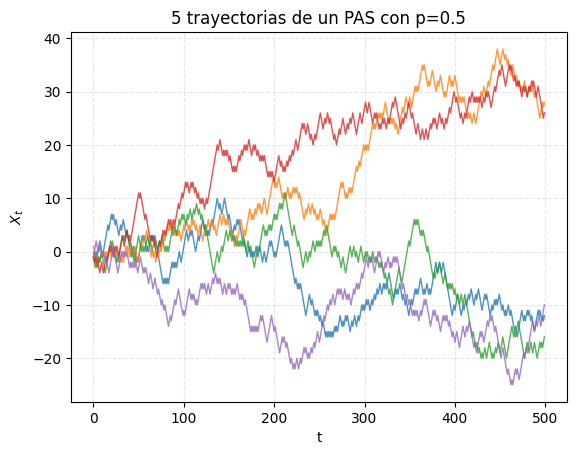

In [5]:
visualizar_PAS(p=0.5, n=500, reps=5)

Visualización de 5 trayectorias de un PAS con `p=0.6`.

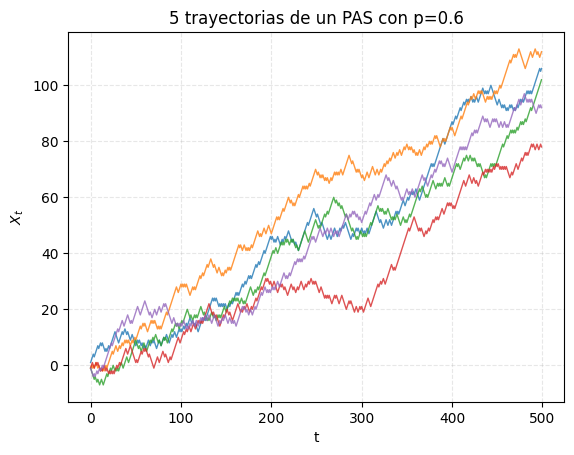

In [6]:
visualizar_PAS(p=0.6, n=500, reps=5)

Visualización de 5 trayectorias de un PAS con `p=0.4`.

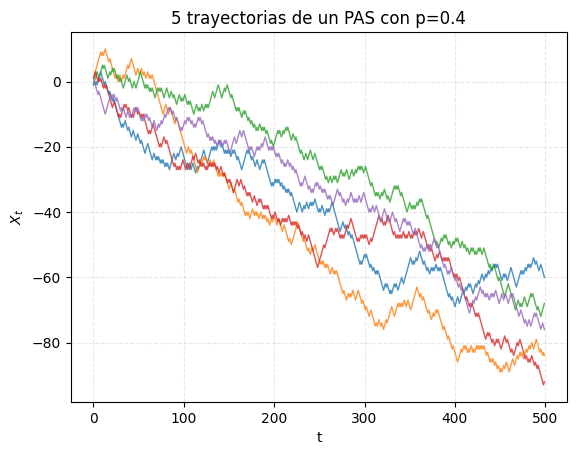

In [7]:
visualizar_PAS(p=0.4, n=500, reps=5)

# Visualización 2: diferentes trayectorias del PAS (con media y desviación típica teóricas)
Ahora usamos `visualizar_PAS` con `mostrar_teoria=True` para visualizar las trayectorias del PAS junto con la media teórica (que en el instante $t$ vale $E[X_t]=(2p−1)t$ ) y un entorno de alrededor de la media de longitud ±1 y ±2 desviaciones típicas teóricas (donde usamos que en el instante $t$ la varianza vale $Var[X_t]=4p(1-p)t$ ).

Posteriormente hacemos algunas pruebas para visualizar 20 trayectorias de un PAS variando el parámetro `p`.

Visualización de 20 trayectorias de un PAS con `p=0.5`.

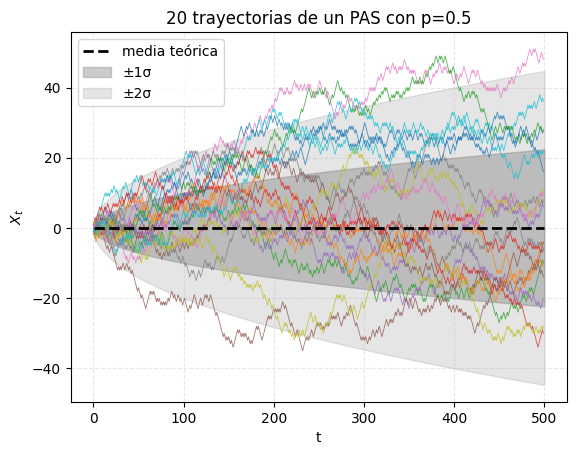

In [8]:
visualizar_PAS(p=0.5, n=500, reps=20, mostrar_teoria=True)

Visualización de 20 trayectorias de un PAS con `p=0.75`.

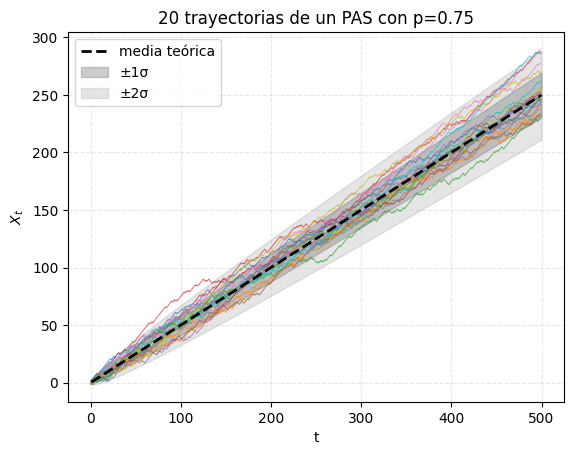

In [9]:
visualizar_PAS(p=0.75, n=500, reps=20, mostrar_teoria=True)

Visualización de 20 trayectorias de un PAS con `p=0.95`.

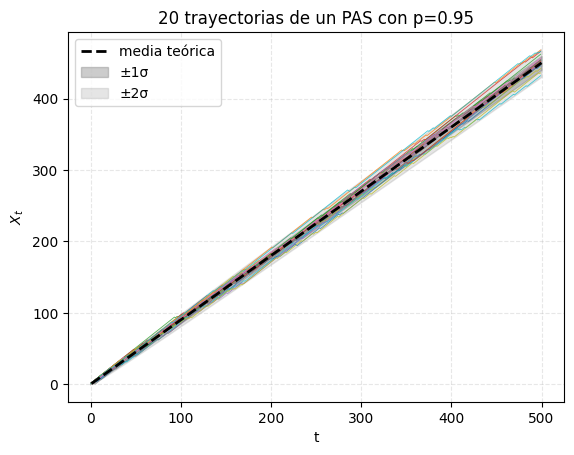

In [10]:
visualizar_PAS(p=0.95, n=500, reps=20, mostrar_teoria=True)

# Visualización 3: visualización de la media empírica del PAS cuando aumentamos el número de trayectorias (junto con la media teórica)
Finalmente creamos una función `media_empirica` que nos permite visualizar cómo se aproxima la media empírica a la media teórica cuando vamos aumentando el número de trayectorias que promediamos. En este caso vamos a promediar 5, 100, 200, 500 y 1000 trayectorias de un PAS con probabilidad `p`.

In [11]:
def media_empirica(p, n):
  plt.figure()
  t = np.arange(1, n + 1)
  trayectorias = simular_PAS(p, n, 1000)
  numero_trayectorias = [5, 100, 200, 500, 1000]
  colores = ["0.0", "0.2", "0.4", "0.6", "0.8"]

  for n_tray, color in zip(numero_trayectorias, colores):
    media_emp = np.mean(trayectorias[:n_tray], axis=0)
    plt.plot(t, media_emp, color=color, label=f"{n_tray}")

  media_teorica = (2 * p - 1) * t
  plt.plot(t, media_teorica, color='red', zorder=1, label='media teórica')

  plt.xlabel('t')
  plt.ylabel('media empírica')
  plt.grid(True, alpha=0.3, linestyle='--')
  plt.title("Media teórica y empírica cuando promediamos varias trayectorias")
  plt.legend(loc='best')
  plt.show()

Hacemos una prueba con `p=0.5`

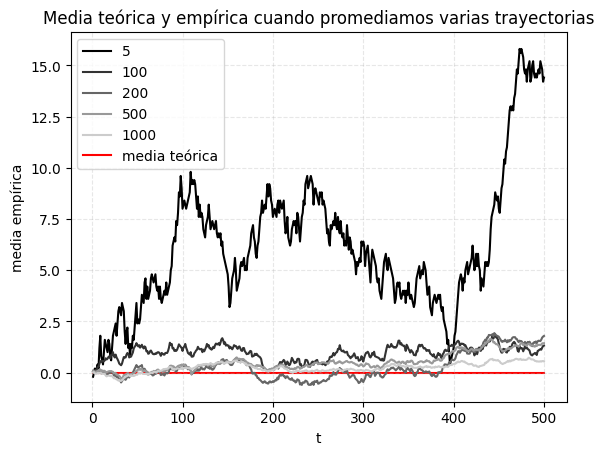

In [12]:
media_empirica(p=0.5, n=500)